# ml_A_intro_codes.ipynb

**文件类型**：配图代码  
**所属章节**：Chapter A  机器学习导论：框架与基础工具  
**课程**：《金融数据分析与建模》Part V · 机器学习  
**作者**：连玉君（中山大学岭南学院）  
**最后更新**：2026-04

**本文件的用途**：生成 Chapter A 讲义中使用的全部配图，保存至 `figs/` 目录。

**输出文件**：
- `figs/fig_A_bias_variance_tradeoff.png`
- `figs/fig_A_norm_balls.png`
- `figs/fig_A_kfold_cv.png`
- `figs/fig_A_walkforward_cv.png`

**运行说明**：按顺序执行所有 Cell，预计耗时约 1–2 分钟。

In [18]:
# ════════════════════════════════════════════════════════════════
# 全局设置（每次使用前必须首先运行此 Cell）
# ════════════════════════════════════════════════════════════════
import os
os.environ.setdefault('MPLCONFIGDIR', os.path.join(os.getcwd(), '.mplconfig'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ── 中文字体支持 ──────────────────────────────────────────────
from matplotlib import font_manager

candidate_fonts = [
    'Microsoft YaHei', 'SimHei', 'SimSun', 'Arial Unicode MS',
    'Noto Sans CJK SC', 'Source Han Sans SC', 'WenQuanYi Micro Hei'
]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
zh_fonts = [f for f in candidate_fonts if f in available_fonts]
ZH_FONT = zh_fonts[0] if zh_fonts else None
if zh_fonts:
    plt.rcParams['font.sans-serif'] = zh_fonts + plt.rcParams['font.sans-serif']
else:
    print('提示：未找到常见中文字体，图中文字可能显示为方框。')
FP = font_manager.FontProperties(family=ZH_FONT) if ZH_FONT else font_manager.FontProperties()
plt.rcParams['axes.unicode_minus'] = False    # 显示负号

# ── 全局图形样式 ───────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'savefig.dpi'       : 300,
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 10,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
})

# ── Part V 统一配色常量 ────────────────────────────────────────
C = {
    'primary'  : '#0B3D91',   # 深蓝：主方法/主曲线
    'secondary': '#B8860B',   # 深金黄：对比方法/验证集
    'tertiary' : '#2F5E9E',   # 蓝：第三曲线
    'neutral'  : '#878787',   # 灰：参考线/次要元素
    'highlight': '#6B4E00',   # 深金棕：最优点/关键标注
    'fill'     : '#D6E2F3',   # 浅蓝：填充/阴影
}

# ── 随机种子（全 Part 统一）────────────────────────────────────
SEED = 42
np.random.seed(SEED)

os.makedirs('figs', exist_ok=True)
print('✅ 全局设置完成')

✅ 全局设置完成


---
## 图 1：偏差-方差-测试误差权衡

**核心思想**：通过蒙特卡洛模拟（重复 200 次），展示随模型复杂度增加，
偏差²、方差、测试误差三条曲线的变化规律。

**数据生成过程（DGP）**：$y = \sin(2\pi x) + \varepsilon$，
$\varepsilon \sim N(0, 0.4^2)$，$x \in [0,1]$

**模型**：多项式回归（degree = 1 至 15）

**偏差-方差分解定理**：$\text{Test MSE} = \text{Bias}^2 + \text{Var} + \sigma^2$

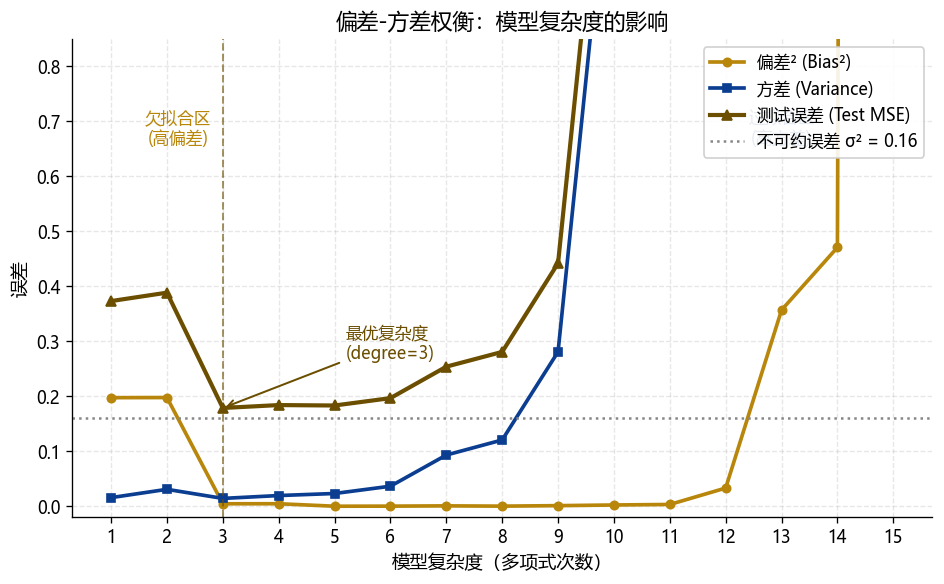

✓ 最优复杂度：degree = 3，Test MSE = 0.1787
  偏差² = 0.0045，方差 = 0.0142，不可约误差 = 0.1600


In [33]:


# ── 参数设置 ────────────────────────────────────────────────────
n_train   = 50      # 每次的训练样本量
n_test    = 500     # 测试集样本量（固定，用于计算偏差）
n_rep     = 200     # 重复次数（模拟"换一批训练数据"的过程）
noise_std = 0.4     # 误差标准差
degrees   = list(range(1, 16))  # 多项式次数候选：1 到 15

# 真实数据生成函数（学生不可知，模型需从数据中学习）
def true_f(x):
    return np.sin(2 * np.pi * x)

# 固定测试集（无噪声，用于计算偏差²：E[f̂] 与真实 f 的差距）
x_test       = np.linspace(0, 1, n_test)
y_test_clean = true_f(x_test)

# ── 蒙特卡洛模拟：重复 n_rep 次，每次换一批训练数据 ────────────
all_preds = {d: np.zeros((n_rep, n_test)) for d in degrees}

for rep in range(n_rep):
    x_tr = np.random.uniform(0, 1, n_train)
    y_tr = true_f(x_tr) + np.random.normal(0, noise_std, n_train)
    for d in degrees:
        mdl = Pipeline([
            ('poly', PolynomialFeatures(degree=d, include_bias=False)),
            ('lr',   LinearRegression())
        ])
        mdl.fit(x_tr.reshape(-1, 1), y_tr)
        all_preds[d][rep] = mdl.predict(x_test.reshape(-1, 1))

# ── 计算偏差²、方差、测试 MSE ───────────────────────────────────
sigma2 = noise_std ** 2   # 不可约误差
bias2_l, var_l, mse_l = [], [], []

for d in degrees:
    preds     = all_preds[d]
    mean_pred = preds.mean(axis=0)    # 200 次预测均值，近似 E[f̂(x)]

    # 偏差²：系统误差（模型结构局限导致的偏离）
    bias2 = np.mean((mean_pred - y_test_clean) ** 2)
    # 方差：随机误差（对训练数据敏感程度）
    var   = np.mean(preds.var(axis=0))
    # 测试 MSE = 偏差² + 方差 + 不可约误差
    mse   = bias2 + var + sigma2

    bias2_l.append(bias2)
    var_l.append(var)
    mse_l.append(mse)

# ── 绘图 ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(degrees, bias2_l, color=C['secondary'], lw=2.2,
        marker='o', markersize=5, label='偏差² (Bias²)')
ax.plot(degrees, var_l,   color=C['primary'],   lw=2.2,
        marker='s', markersize=5, label='方差 (Variance)')
ax.plot(degrees, mse_l,   color=C['highlight'], lw=2.5,
        marker='^', markersize=6, label='测试误差 (Test MSE)')
ax.axhline(sigma2, color=C['neutral'], lw=1.5, ls=':',
           label=f'不可约误差 σ² = {sigma2:.2f}')

# 标注最优复杂度
best_d   = degrees[np.argmin(mse_l)]
best_mse = min(mse_l)
ax.axvline(best_d, color=C['highlight'], lw=1.2, ls='--', alpha=0.6)

ax.annotate(f'最优复杂度\n(degree={best_d})',
            xy=(best_d, best_mse), xytext=(best_d + 2.2, best_mse + 0.09),
            fontsize=10, color=C['highlight'],
            arrowprops=dict(arrowstyle='->', color=C['highlight'], lw=1.2))

# 区域标注
ax.text(2.2, 0.66, '欠拟合区\n(高偏差)', fontsize=10,
        color=C['secondary'], ha='center')
ax.text(13.0, 0.66, '过拟合区\n(高方差)', fontsize=10,
        color=C['primary'], ha='center')

ax.set_xlabel('模型复杂度（多项式次数）', fontsize=11)
ax.set_ylabel('误差', fontsize=11)
ax.set_title('偏差-方差权衡：模型复杂度的影响', fontsize=13)
ax.set_xticks(degrees)
ax.set_ylim(-0.02, 0.85)
ax.legend(loc='upper right', framealpha=0.9)

fig.tight_layout()
fig.savefig('figs/fig_A_bias_variance_tradeoff.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ 最优复杂度：degree = {best_d}，Test MSE = {best_mse:.4f}')
print(f'  偏差² = {bias2_l[best_d-1]:.4f}，方差 = {var_l[best_d-1]:.4f}，不可约误差 = {sigma2:.4f}')

呈现原始数据的散点图、真实函数曲线、三条拟合曲线 (degree=1, 2, 3)。

In [ ]:
# 固定一组演示样本，便于比较不同复杂度下的拟合效果
rng = np.random.default_rng(SEED)
x_demo = np.sort(rng.uniform(0, 1, n_train))
y_demo = true_f(x_demo) + rng.normal(0, noise_std, n_train)

x_grid = x_test if 'x_test' in globals() else np.linspace(0, 1, 500)
y_true = true_f(x_grid)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True)

for ax, d in zip(axes, [1, 2, 3]):
    mdl = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('lr', LinearRegression())
    ])
    mdl.fit(x_demo.reshape(-1, 1), y_demo)
    y_fit = mdl.predict(x_grid.reshape(-1, 1))

    ax.scatter(x_demo, y_demo, s=24, color=C['neutral'], alpha=0.75, label='训练样本')
    ax.plot(x_grid, y_true, color=C['primary'], lw=2.2, label='真实函数')
    ax.plot(x_grid, y_fit, color=C['secondary'], lw=2.2, ls='--', label=f'拟合曲线 (degree={d})')

    ax.set_title(f'多项式次数 = {d}', fontsize=12)
    ax.set_xlabel('x')
    ax.set_xlim(0, 1)
    ax.set_ylim(-1.8, 1.8)
    ax.grid(True, alpha=0.25, ls='--')

axes[0].set_ylabel('y')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, framealpha=0.9, bbox_to_anchor=(0.5, 1.05))
fig.suptitle('原始数据、真实函数与不同复杂度的拟合效果', fontsize=13, y=1.12)

fig.tight_layout()
plt.show()

In [ ]:
# 呈现原始数据的散点图、真实函数曲线、三条拟合曲线 (degree=1, 2, 3)。



---
## 图 2：四种范数约束集（单位球）

展示 ℓ₀.₅（非凸）、ℓ₁（Lasso）、ℓ₂（Ridge）、ℓ∞ 四种范数的约束集形状，
直观说明为什么 ℓ₁ 是稀疏性与凸性的「甜点」。

**约束集定义**：$\{(\beta_1, \beta_2) : |\beta_1|^q + |\beta_2|^q \leq 1\}$

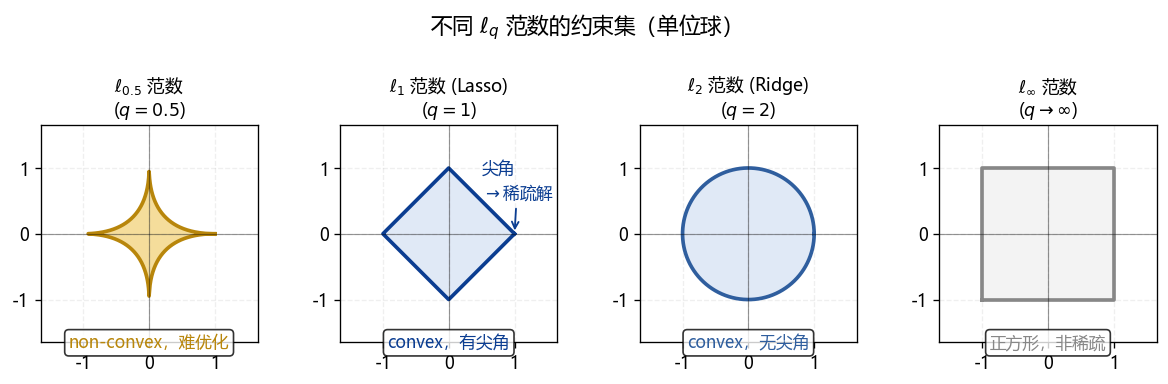

✓ fig_A_norm_balls.png 已保存


In [29]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.6))
fig.subplots_adjust(wspace=0.38)

# 每种范数配置：(q 值, 标题, 填充色, 边框色, 注释)
configs = [
    (0.5,    '$\\ell_{0.5}$ 范数\n($q = 0.5$)',       '#F2D27A', C['secondary'], 'non-convex，难优化'),
    (1.0,    '$\\ell_1$ 范数 (Lasso)\n($q = 1$)',   C['fill'], C['primary'],   'convex，有尖角'),
    (2.0,    '$\\ell_2$ 范数 (Ridge)\n($q = 2$)',   '#D6E2F3', C['tertiary'],  'convex，无尖角'),
    (np.inf, '$\\ell_\\infty$ 范数\n($q \\to \\infty$)', '#F0F0F0', C['neutral'],   '正方形，非稀疏'),
]

t = np.linspace(0, 2 * np.pi, 2000)

for ax, (q, title, fc, ec, note) in zip(axes, configs):
    if np.isinf(q):
        # ℓ∞：正方形 max(|β₁|, |β₂|) = 1
        sq = np.array([[-1,-1],[1,-1],[1,1],[-1,1],[-1,-1]])
        ax.fill(sq[:,0], sq[:,1], color=fc, alpha=0.75)
        ax.plot(sq[:,0], sq[:,1], color=ec, lw=2.2)
    else:
        # 数值法：极坐标 r = (|cosθ|^q + |sinθ|^q)^(-1/q)
        xs, ys = [], []
        for ti in t:
            ct, st = np.cos(ti), np.sin(ti)
            d = abs(ct)**q + abs(st)**q
            if d > 1e-9:
                r = d ** (-1/q)
                xs.append(r * ct); ys.append(r * st)
        ax.fill(xs, ys, color=fc, alpha=0.75)
        ax.plot(xs, ys, color=ec, lw=2.2)

    ax.axhline(0, color='black', lw=0.7, alpha=0.4)
    ax.axvline(0, color='black', lw=0.7, alpha=0.4)
    ax.set_xlim(-1.65, 1.65); ax.set_ylim(-1.65, 1.65)
    ax.set_aspect('equal')
    ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
    ax.tick_params(labelsize=10)
    ax.set_title(title, fontproperties=FP, fontsize=10.5, pad=6)
    ax.spines['top'].set_visible(True); ax.spines['right'].set_visible(True)
    ax.text(0, -1.52, note, fontproperties=FP, fontsize=10,
            ha='center', va='top', color=ec,
            bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8))
    ax.grid(True, alpha=0.2, ls='--')

# 标注 ℓ₁ 的"尖角"——稀疏解的几何根源
axes[1].annotate('尖角\n$\\to$稀疏解',
                 xy=(1.0, 0.0), xytext=(0.5, 0.55),
                 fontproperties=FP, fontsize=10, color=C['primary'],
                 arrowprops=dict(arrowstyle='->', color=C['primary'], lw=1.1))

fig.suptitle('不同 $\\ell_q$ 范数的约束集（单位球）',
             fontproperties=FP, fontsize=13, y=1.01)
fig.savefig('figs/fig_A_norm_balls.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ fig_A_norm_balls.png 已保存')

---
## 图 3：K 折交叉验证示意（K = 5）

色块图展示 K 折 CV 的数据分割方式。每轮用 K-1 折训练（蓝色），1 折验证（橙红色）。
K 轮结束后，每个样本恰好被用作验证集一次，平均 CV 误差作为模型性能估计。

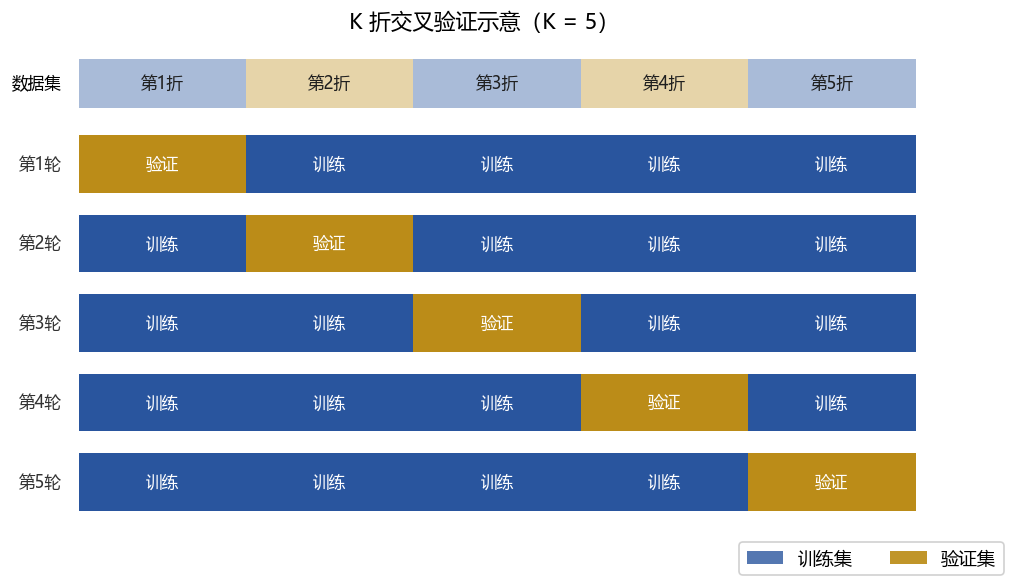

✓ fig_A_kfold_cv.png 已保存


In [21]:
K = 5   # 折数
B = 10  # 每折用 B 个色块表示（纯视觉，不代表真实样本数）

fig, axes = plt.subplots(K + 1, 1, figsize=(9, 5.0))
fig.subplots_adjust(top=0.92, bottom=0.13, hspace=0.04)

# 顶部：原始数据集（交替色块，标注折编号）
ax0 = axes[0]
for b in range(K * B):
    fi  = b // B
    col = C['primary'] if fi % 2 == 0 else C['secondary']
    ax0.barh(0, 1, left=b, height=0.6,
             color=col, alpha=0.35, edgecolor='none', lw=0)
for k in range(K):
    ax0.text(k*B + B/2, 0, f'第{k+1}折',
             fontsize=10,
             ha='center', va='center', color='#1f1f1f')
ax0.set_xlim(0, K*B); ax0.set_ylim(-0.38, 0.55); ax0.axis('off')
ax0.text(-1, 0, '数据集', fontsize=10,
         ha='right', va='center')

# 每轮：训练（深蓝）/ 验证（深金黄）
for k in range(K):
    ax = axes[k + 1]
    for b in range(K * B):
        fi = b // B
        col   = C['secondary'] if fi == k else C['primary']
        alpha = 0.95           if fi == k else 0.88
        ax.barh(0, 1, left=b, height=0.65,
                color=col, alpha=alpha, edgecolor='none', lw=0)
    for kk in range(K):
        txt = '验证' if kk == k else '训练'
        ax.text(kk*B + B/2, 0, txt, fontsize=10,
                ha='center', va='center', color='white')
    ax.set_xlim(0, K*B); ax.set_ylim(-0.34, 0.52); ax.axis('off')
    ax.text(-1, 0, f'第{k+1}轮', fontsize=10,
            ha='right', va='center', color='#333')

legend_elements = [
    mpatches.Patch(facecolor=C['primary'],   alpha=0.7,  label='训练集'),
    mpatches.Patch(facecolor=C['secondary'], alpha=0.88, label='验证集'),
]
fig.legend(handles=legend_elements, prop=FP, loc='lower right',
           bbox_to_anchor=(0.99, 0.01), ncol=2, framealpha=0.9)
fig.suptitle('K 折交叉验证示意（K = 5）',
             fontsize=13, y=0.965)
fig.savefig('figs/fig_A_kfold_cv.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ fig_A_kfold_cv.png 已保存')

---
## 图 4：前向滚动验证示意（金融时序数据）

金融时序数据不能随机分折，必须保持时间顺序。
**扩展窗口**：每轮训练集向后延伸，验证集向后滚动一年（2000–2025）。

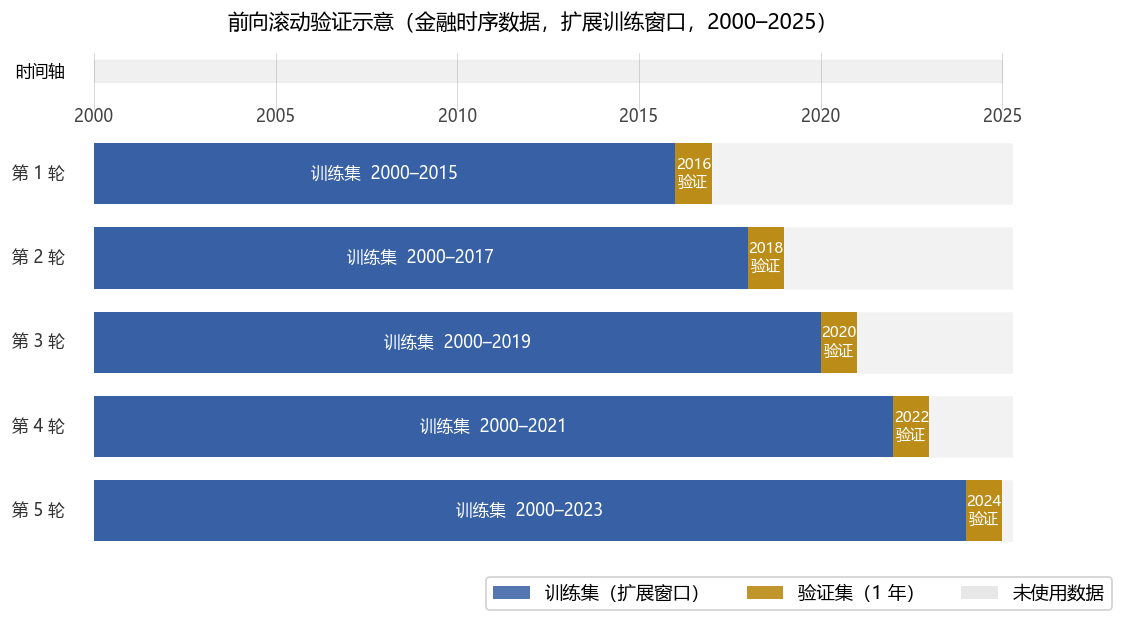

✓ fig_A_walkforward_cv.png 已保存


In [25]:
t0, t1 = 2000, 2025   # 数据起止年份
span   = t1 - t0      # 总时间跨度：25 年

# 5 轮配置：(训练集结束年, 验证年)
rounds = [(2015,2016),(2017,2018),(2019,2020),(2021,2022),(2023,2024)]

fig, axes = plt.subplots(len(rounds) + 1, 1, figsize=(10, 5.3))
fig.subplots_adjust(top=0.92, bottom=0.13, hspace=0.04)

# 顶部时间轴
ax0 = axes[0]
ax0.barh(0, span, left=0, height=0.4,
         color=C['neutral'], alpha=0.12, edgecolor='#aaa', lw=0.8)
for yr in range(t0, t1 + 1, 5):
    x = yr - t0
    ax0.text(x, -0.65, str(yr), fontsize=10,
             ha='center', va='top', color='#444')
    ax0.axvline(x, color='gray', lw=0.5, alpha=0.35, ymin=0.15, ymax=0.85)
ax0.set_xlim(-0.3, span+0.3); ax0.set_ylim(-0.9, 0.55); ax0.axis('off')
ax0.text(-0.8, 0, '时间轴', fontsize=10,
         ha='right', va='center')

# 各轮：训练（深蓝，扩展窗口）+ 验证（深金黄，1 年）+ 未用（灰）
for i, (tr_end, val_yr) in enumerate(rounds):
    ax = axes[i + 1]

    tr_w = tr_end - t0 + 1   # 训练集时间跨度（年）
    ax.barh(0, tr_w, left=0, height=0.65,
            color=C['primary'], alpha=0.82, edgecolor='none', lw=0)
    ax.text(tr_w/2, 0, f'训练集  {t0}–{tr_end}',
            fontsize=10,
            ha='center', va='center', color='white')

    val_left = val_yr - t0
    ax.barh(0, 1, left=val_left, height=0.65,
            color=C['secondary'], alpha=0.95, edgecolor='none', lw=0)
    ax.text(val_left+0.5, 0, f'{val_yr}\n验证',
            fontsize=9,
            ha='center', va='center', color='white')

    unused_left = val_yr + 1 - t0
    unused_w    = t1 - val_yr
    if unused_w > 0:
        ax.barh(0, unused_w, left=unused_left, height=0.65,
                color=C['neutral'], alpha=0.10, edgecolor='#ccc', lw=0.4)

    ax.set_xlim(-0.3, span+0.3); ax.set_ylim(-0.34, 0.52); ax.axis('off')
    ax.text(-0.8, 0, f'第 {i+1} 轮', fontsize=10,
            ha='right', va='center', color='#333')

legend_elements = [
    mpatches.Patch(facecolor=C['primary'],   alpha=0.7,  label='训练集（扩展窗口）'),
    mpatches.Patch(facecolor=C['secondary'], alpha=0.88, label='验证集（1 年）'),
    mpatches.Patch(facecolor=C['neutral'],   alpha=0.2,  label='未使用数据'),
]
fig.legend(handles=legend_elements, prop=FP, loc='lower right',
           bbox_to_anchor=(0.99, 0.01), ncol=3, framealpha=0.9)
fig.suptitle('前向滚动验证示意（金融时序数据，扩展训练窗口，2000–2025）',
             fontsize=12.5, y=0.965)
fig.savefig('figs/fig_A_walkforward_cv.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ fig_A_walkforward_cv.png 已保存')

In [23]:
# ── 汇总确认 ────────────────────────────────────────────────────
print('\n' + '='*55)
print('✅ 所有图形已生成并保存至 figs/ 目录')
print()
for f in sorted(os.listdir('figs')):
    if f.startswith('fig_A'):
        sz = os.path.getsize(f'figs/{f}') / 1024
        print(f'   {f}  ({sz:.0f} KB)')
print()
print('在 ml_A_intro_lec.qmd 中引用方式：')
for tag, fname in [
    ('fig-A-bias-variance-tradeoff', 'fig_A_bias_variance_tradeoff.png'),
    ('fig-A-norm-balls',             'fig_A_norm_balls.png'),
    ('fig-A-kfold-cv',               'fig_A_kfold_cv.png'),
    ('fig-A-walkforward-cv',         'fig_A_walkforward_cv.png'),
]:
    print(f'  ![]( figs/{fname}){{#{tag}}}')


✅ 所有图形已生成并保存至 figs/ 目录

   fig_A_bias_variance_tradeoff.png  (111 KB)
   fig_A_kfold_cv.png  (49 KB)
   fig_A_norm_balls.png  (70 KB)
   fig_A_walkforward_cv.png  (81 KB)

在 ml_A_intro_lec.qmd 中引用方式：
  ![]( figs/fig_A_bias_variance_tradeoff.png){#fig-A-bias-variance-tradeoff}
  ![]( figs/fig_A_norm_balls.png){#fig-A-norm-balls}
  ![]( figs/fig_A_kfold_cv.png){#fig-A-kfold-cv}
  ![]( figs/fig_A_walkforward_cv.png){#fig-A-walkforward-cv}
